<a href="https://colab.research.google.com/github/fabianoseller/PucPosEstat/blob/main/Lista2_versao01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Exercício 1 –  A partir da base de dados propaganda.csv Download "propaganda.csv" faça um modelo de regressão múltipla para predizer as vendas:

1 – Análise descritiva

2 – Calculo de correlação e covariância

3 – Faça o modelo de regressão

4 – Realize a análise de resíduos

5 – Análise de multicolinearidade

6 – Análise do Modelo



## Exercício 2 - Faça 3 modelos de regressão linear múltipla para predizer da melhor forma possível o preço dos automóveis.

preco_carro.csvDownload ("preco_carro.csv")

1º Modelo com todas variáveis

2º Modelo com as 3 variáveis mais correlacionadas

3º Modelo com as 5 variáveis mais correlacionadas

   

*Na análise de dados e do modelo devem contemplar:*

1 – Análise descritiva

2 – Calculo de correlação e covariância

3 – Faça o modelo de regressão

4 – Realize a análise de resíduos

5 – Análise de multicolinearidade

6 – Análise de outlier

7 – Comparação de modelos

In [ ]:
# Carregar pacotes necessários
# Se você ainda não os tem instalados, descomente e rode as linhas abaixo:
# install.packages("dplyr")
# install.packages("readr")
# install.packages("tidyr")
# install.packages("ggplot2") # Pode ser útil para visualizações futuras, mas não essencial aqui.
# install.packages("stats") # Geralmente já vem com o R base
# install.packages("car") # Descomente e execute se não tiver o pacote

# Attempt to install car with dependencies if needed
if (!requireNamespace("car", quietly = TRUE)) {
  install.packages("car", dependencies = TRUE)
}

library(dplyr)   # Para manipulação de dados
library(readr)   # Para ler arquivos CSV
library(tidyr)   # Para arrumar dados
library(ggplot2) # Para gráficos
library(scales)  # Para formatar o eixo Y como porcentagem no gráfico
library(stats)   # Para prop.test e outras funções estatísticas (geralmente base R)
library(car)     # Para análise de regressão e VIF

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘R.oo’, ‘R.methodsS3’, ‘bdsmatrix’, ‘colorspace’, ‘estimability’, ‘insight’, ‘zoo’, ‘ucminf’, ‘writexl’, ‘R.utils’, ‘mitools’, ‘RcppArmadillo’, ‘pbkrtest’, ‘lme4’, ‘alr4’, ‘coxme’, ‘effects’, ‘leaps’, ‘lmtest’, ‘ordinal’, ‘plotrix’, ‘mvtnorm’, ‘rgl’, ‘rio’, ‘sandwich’, ‘survey’



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘readr’


The following object is masked from ‘package:scales’:

    col_factor


Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode




[1] "Primeiras linhas do dataset:"
     TV Radio Jornal Vendas
1 230.1  37.8   69.2   22.1
2  44.5  39.3   45.1   10.4
3  17.2  45.9   69.3    9.3
4 151.5  41.3   58.5   18.5
5 180.8  10.8   58.4   12.9
6   8.7  48.9   75.0    7.2
[1] "Resumo estatístico das variáveis:"
       TV             Radio            Jornal           Vendas     
 Min.   :  0.70   Min.   : 0.000   Min.   :  0.30   Min.   : 1.60  
 1st Qu.: 74.38   1st Qu.: 9.975   1st Qu.: 12.75   1st Qu.:10.38  
 Median :149.75   Median :22.900   Median : 25.75   Median :12.90  
 Mean   :147.04   Mean   :23.264   Mean   : 30.55   Mean   :14.02  
 3rd Qu.:218.82   3rd Qu.:36.525   3rd Qu.: 45.10   3rd Qu.:17.40  
 Max.   :296.40   Max.   :49.600   Max.   :114.00   Max.   :27.00  


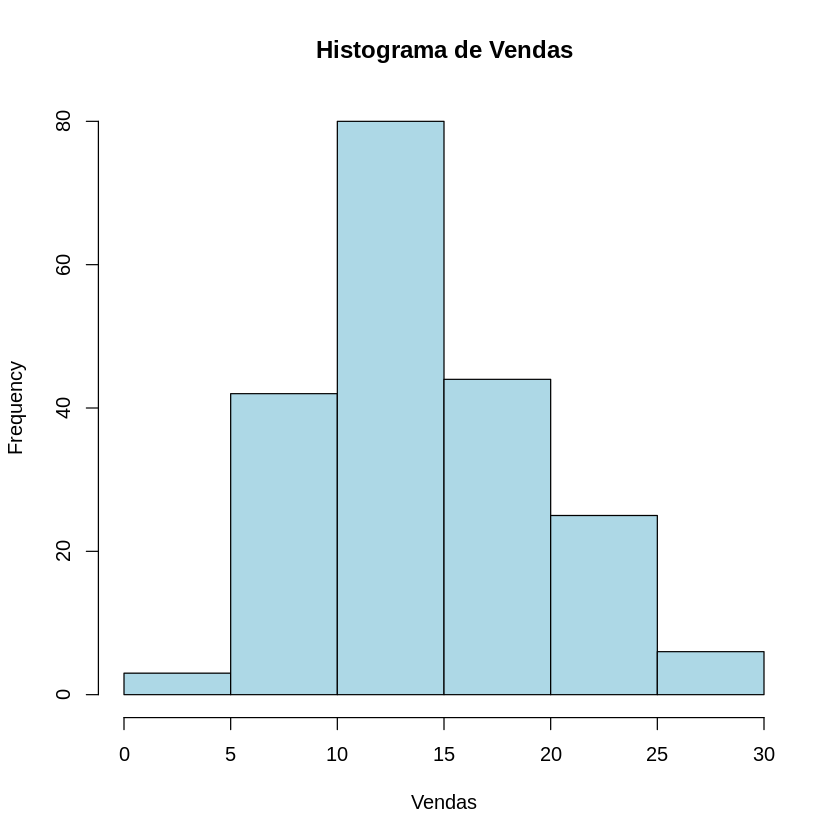

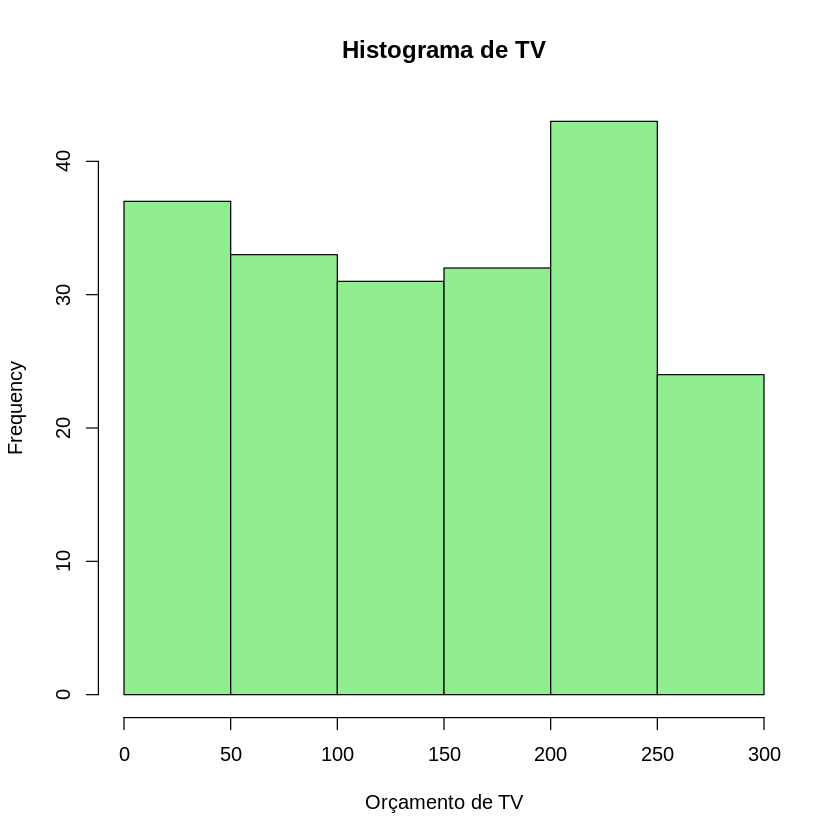

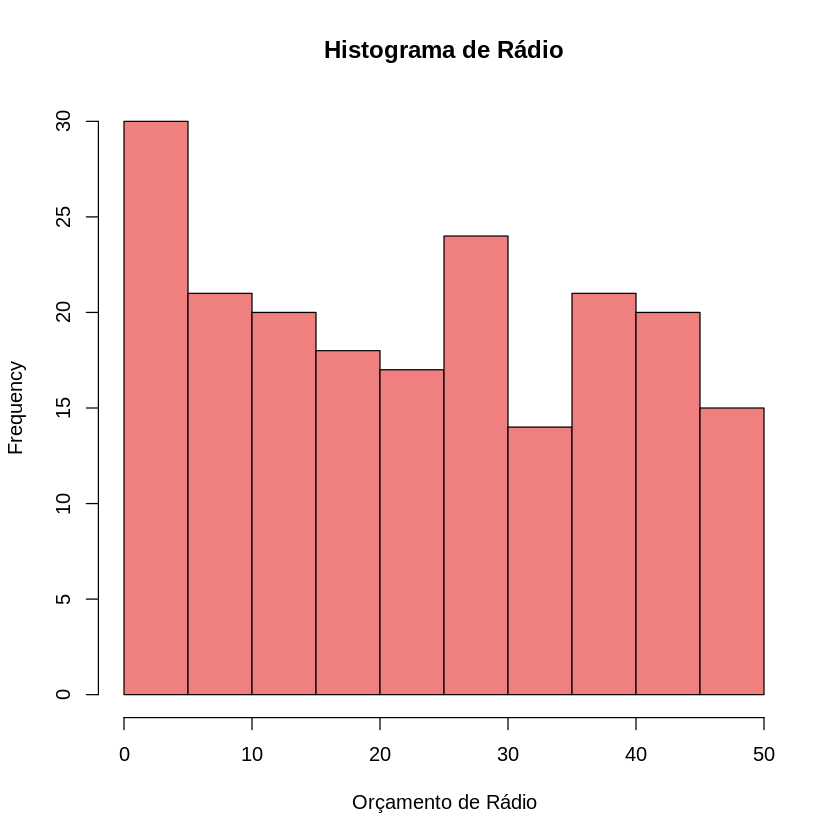

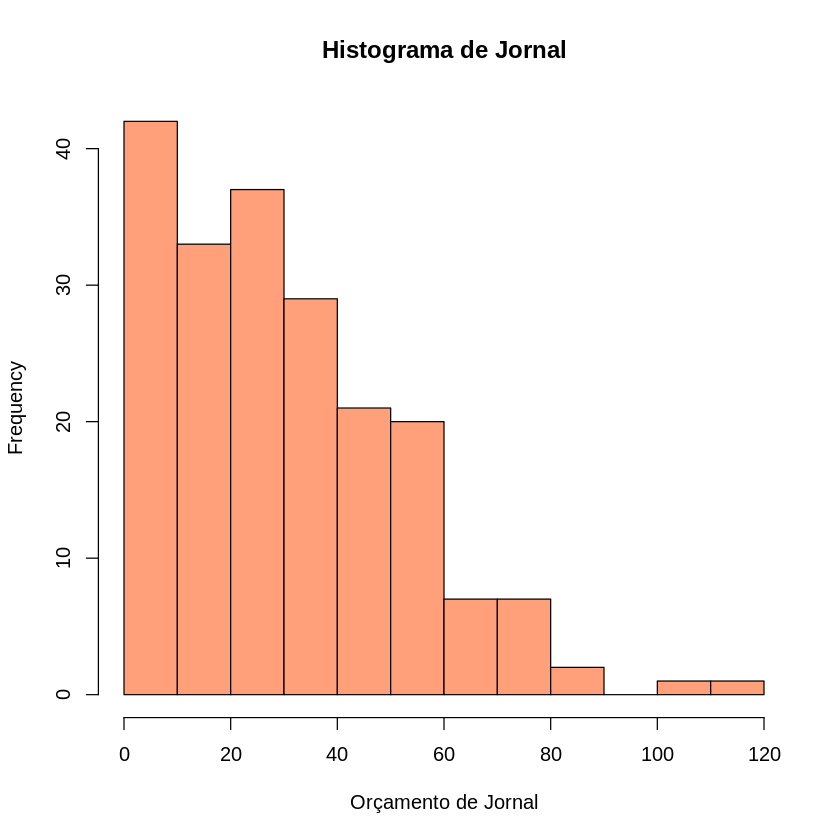

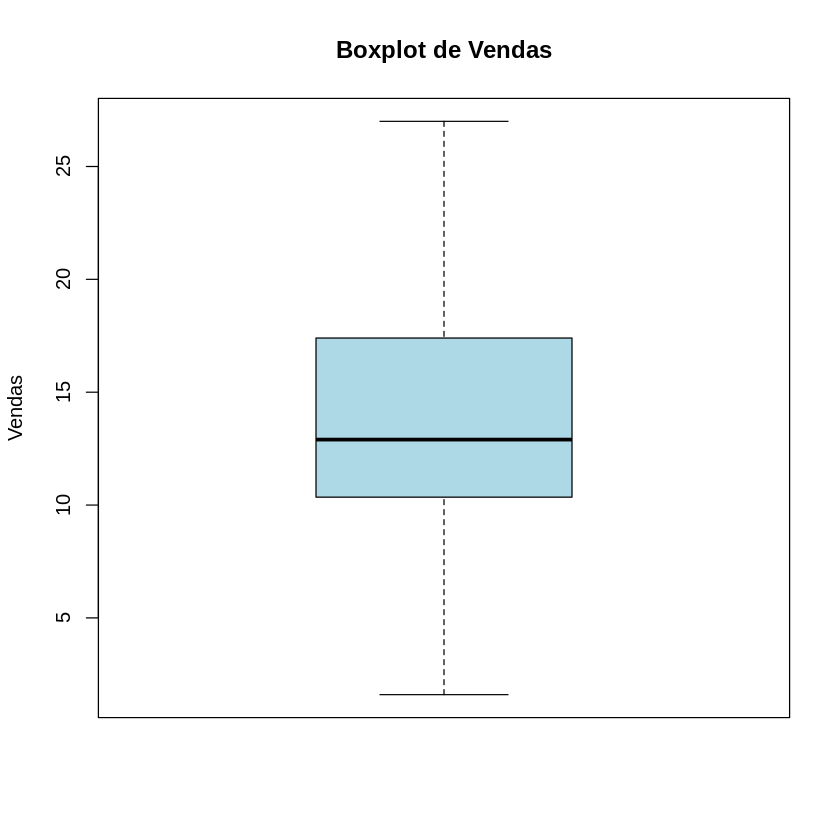

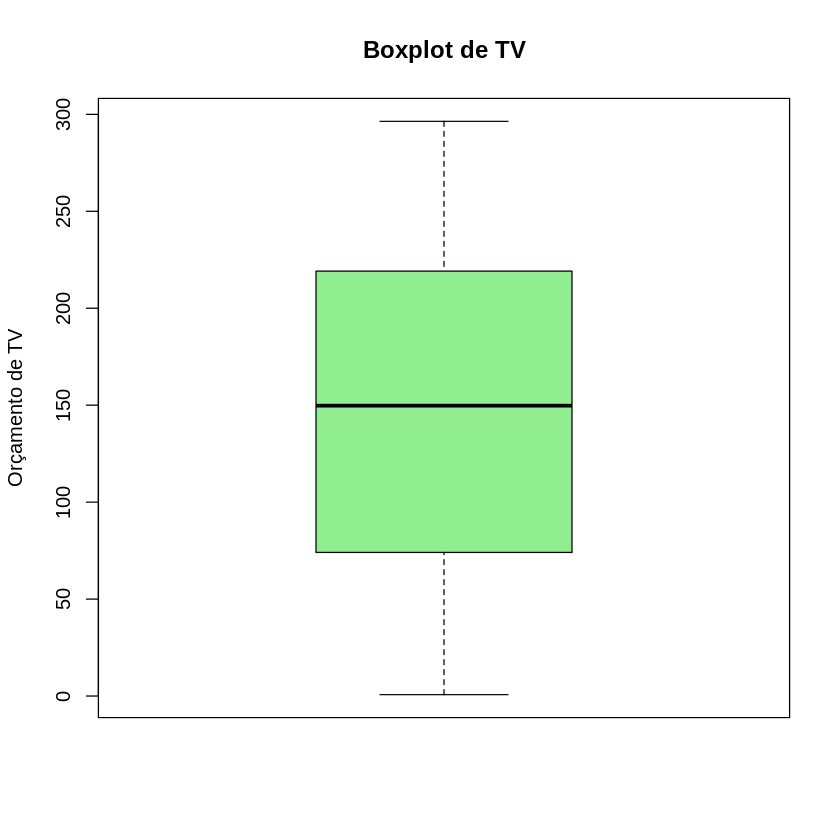

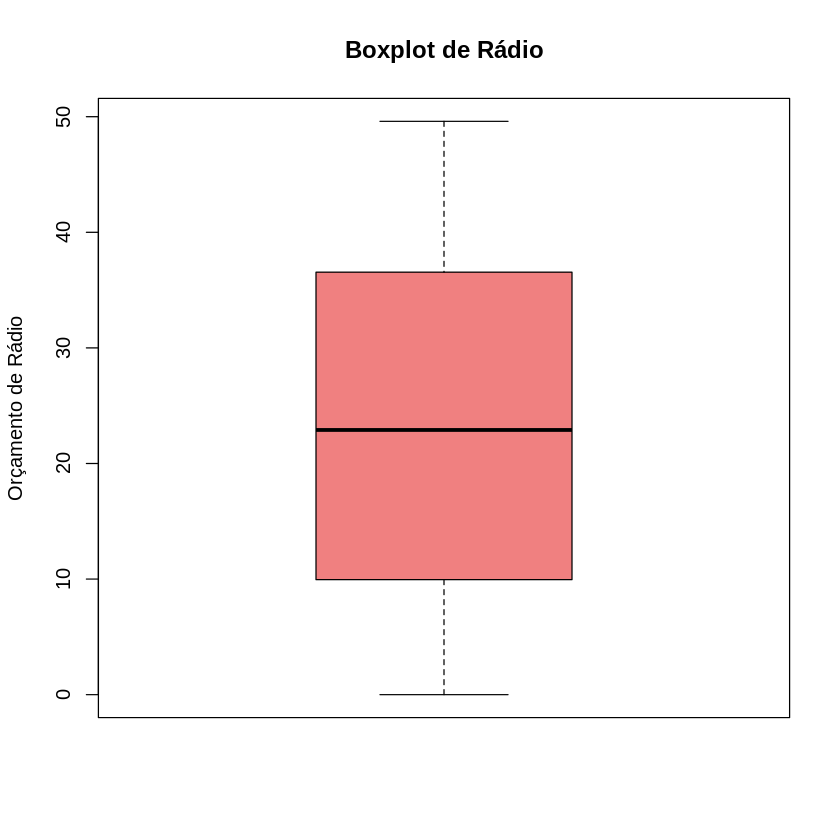

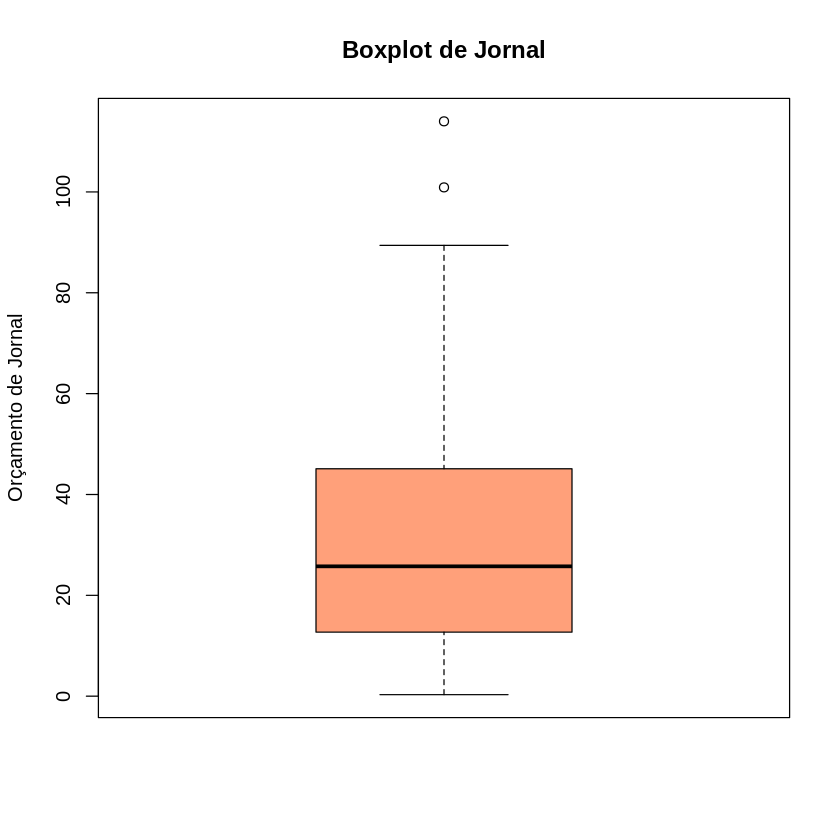

In [ ]:
# Carregar o dataset
dados <- read.csv("propaganda.csv")

# Visualizar as primeiras linhas do dataset
print("Primeiras linhas do dataset:")
print(head(dados))

# Resumo estatístico das variáveis
print("Resumo estatístico das variáveis:")
print(summary(dados))

# Para visualizar a distribuição das variáveis (opcional, mas recomendado)
# Histograma das Vendas
hist(dados$Vendas,
     main = "Histograma de Vendas",
     xlab = "Vendas",
     col = "lightblue",
     border = "black")

# Histograma da TV
hist(dados$TV,
     main = "Histograma de TV",
     xlab = "Orçamento de TV",
     col = "lightgreen",
     border = "black")

# Histograma do Rádio
hist(dados$Radio,
     main = "Histograma de Rádio",
     xlab = "Orçamento de Rádio",
     col = "lightcoral",
     border = "black")

# Histograma do Jornal
hist(dados$Jornal,
     main = "Histograma de Jornal",
     xlab = "Orçamento de Jornal",
     col = "lightsalmon",
     border = "black")

# Boxplot das Vendas
boxplot(dados$Vendas,
        main = "Boxplot de Vendas",
        ylab = "Vendas",
        col = "lightblue")

# Boxplot do TV
boxplot(dados$TV,
        main = "Boxplot de TV",
        ylab = "Orçamento de TV",
        col = "lightgreen")

# Boxplot do Rádio
boxplot(dados$Radio,
        main = "Boxplot de Rádio",
        ylab = "Orçamento de Rádio",
        col = "lightcoral")

# Boxplot do Jornal
boxplot(dados$Jornal,
        main = "Boxplot de Jornal",
        ylab = "Orçamento de Jornal",
        col = "lightsalmon")

# 2. Cálculo de Correlação e Covariância
## Esta etapa calcula as matrizes de correlação e covariância entre as variáveis, o que ajuda a entender a relação linear entre elas.

[1] "Matriz de Correlação:"
               TV      Radio     Jornal    Vendas
TV     1.00000000 0.05480866 0.05664787 0.7822244
Radio  0.05480866 1.00000000 0.35410375 0.5762226
Jornal 0.05664787 0.35410375 1.00000000 0.2282990
Vendas 0.78222442 0.57622257 0.22829903 1.0000000
[1] "Matriz de Covariância:"


function (...)  .Primitive("c")

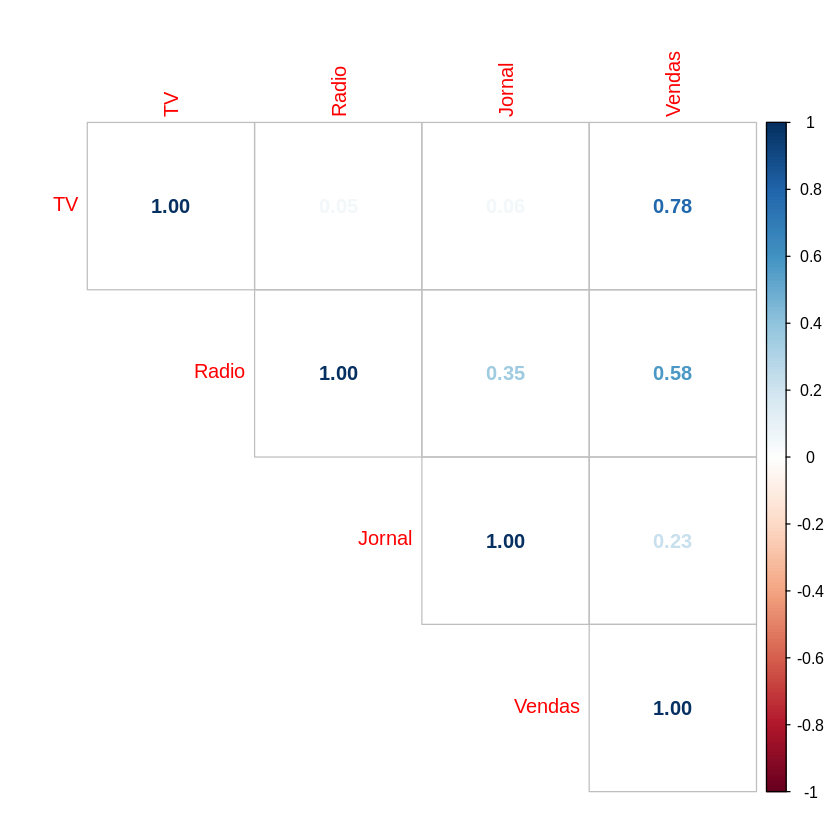

In [ ]:

# Cálculo da matriz de correlação
print("Matriz de Correlação:")
print(cor(dados))

# Cálculo da matriz de covariância
print("Matriz de Covariância:")
c

# Visualização da matriz de correlação (opcional, usando o pacote corrplot)
# install.packages("corrplot") # Descomente e execute se não tiver o pacote
library(corrplot)
corrplot(cor(dados), method = "number", type = "upper")

#3. Faça o Modelo de Regressão
## Aqui construiremos o modelo de regressão múltipla, onde "vendas" é a variável dependente e "TV", "radio" e "jornal" são as variáveis independentes

In [ ]:
# Construir o modelo de regressão múltipla
modelo_regressao <- lm(Vendas ~ TV + Radio + Jornal, data = dados)

# Resumo do modelo
print("Resumo do Modelo de Regressão:")
print(summary(modelo_regressao))

[1] "Resumo do Modelo de Regressão:"

Call:
lm(formula = Vendas ~ TV + Radio + Jornal, data = dados)

Residuals:
    Min      1Q  Median      3Q     Max 
-8.8277 -0.8908  0.2418  1.1893  2.8292 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  2.938889   0.311908   9.422   <2e-16 ***
TV           0.045765   0.001395  32.809   <2e-16 ***
Radio        0.188530   0.008611  21.893   <2e-16 ***
Jornal      -0.001037   0.005871  -0.177     0.86    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.686 on 196 degrees of freedom
Multiple R-squared:  0.8972,	Adjusted R-squared:  0.8956 
F-statistic: 570.3 on 3 and 196 DF,  p-value: < 2.2e-16



# 4. Realize a Análise de Resíduos
## A análise de resíduos é crucial para verificar as suposições do modelo de regressão (normalidade, homocedasticidade e independência dos erros).

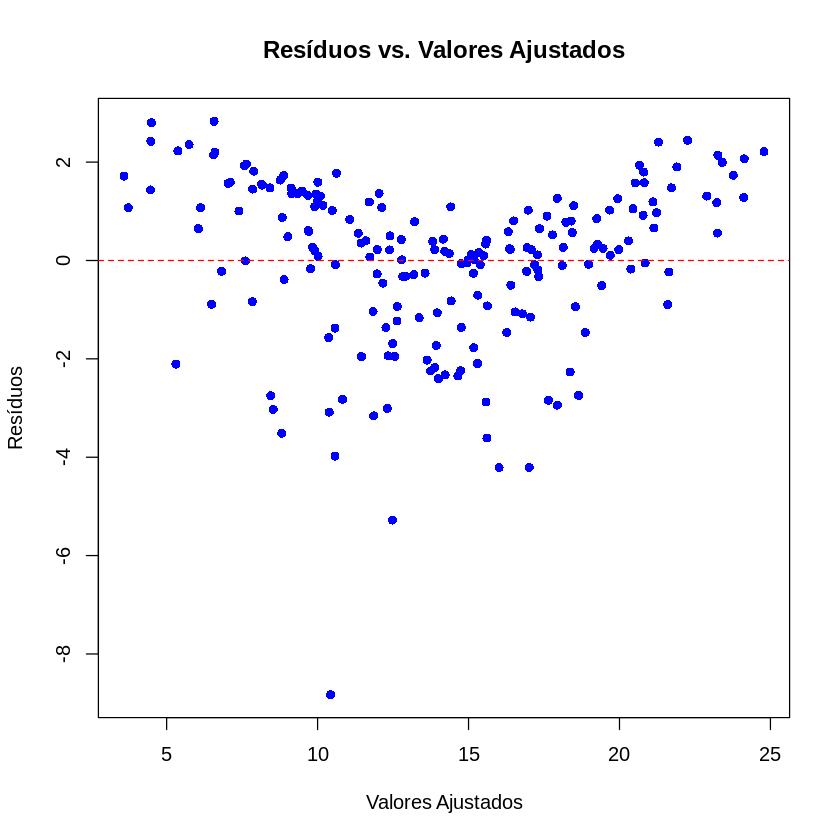

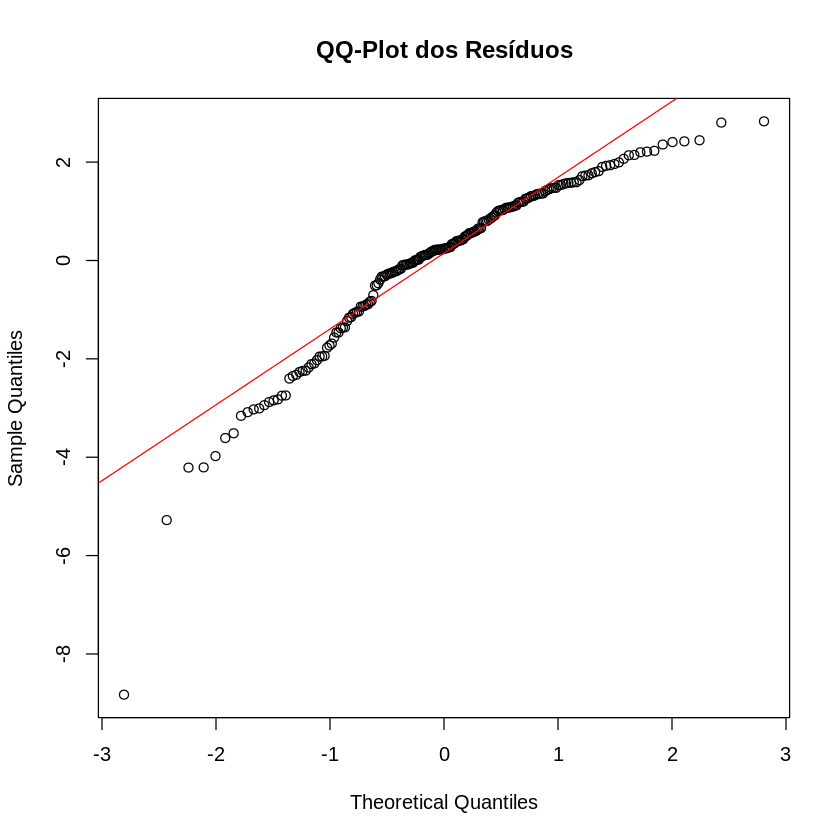

[1] "Teste de Shapiro-Wilk para Normalidade dos Resíduos:"

	Shapiro-Wilk normality test

data:  residuos
W = 0.91767, p-value = 3.939e-09



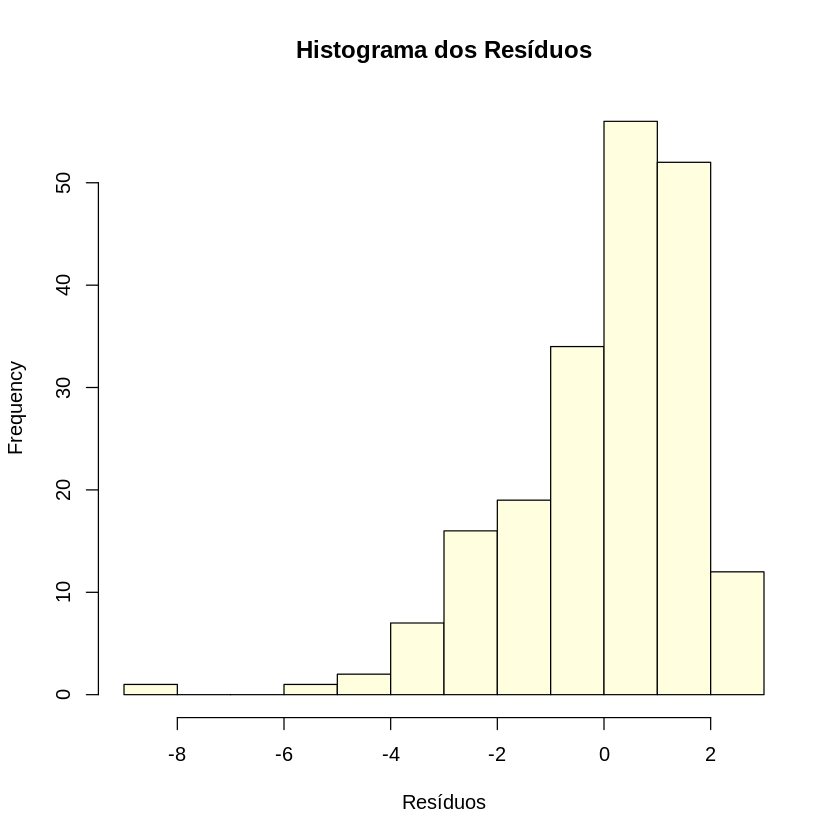

In [ ]:
# Construir o modelo de regressão múltipla (se ainda não construiu)
# modelo_regressao <- lm(vendas ~ TV + radio + jornal, data = dados)

# Obter os resíduos
residuos <- residuals(modelo_regressao)

# Gráfico de Resíduos vs. Valores Ajustados (Verificar Homocedasticidade)
plot(fitted(modelo_regressao), residuos,
     main = "Resíduos vs. Valores Ajustados",
     xlab = "Valores Ajustados",
     ylab = "Resíduos",
     col = "blue",
     pch = 16)
abline(h = 0, col = "red", lty = 2) # Linha de referência em y=0

# QQ-Plot dos Resíduos (Verificar Normalidade)
qqnorm(residuos,
       main = "QQ-Plot dos Resíduos")
qqline(residuos, col = "red")

# Histograma dos Resíduos (Verificar Normalidade)
hist(residuos,
     main = "Histograma dos Resíduos",
     xlab = "Resíduos",
     col = "lightyellow",
     border = "black")

# Teste de Shapiro-Wilk para Normalidade dos Resíduos (opcional)
# H0: os resíduos são normalmente distribuídos
# Se p-valor < 0.05, rejeita H0
print("Teste de Shapiro-Wilk para Normalidade dos Resíduos:")
print(shapiro.test(residuos))

# 5. Análise de Multicolinearidade
# Esta etapa verifica se as variáveis independentes estão altamente correlacionadas entre si, o que pode afetar a estabilidade dos coeficientes do modelo. Usaremos o VIF (Variance Inflation Factor).



In [ ]:
# Construir o modelo de regressão múltipla (se ainda não construiu)
# modelo_regressao <- lm(vendas ~ TV + radio + jornal, data = dados)

# Instalar e carregar o pacote 'car' para VIF
# install.packages("car") # Descomente e execute se não tiver o pacote
library(car)

# Calcular o VIF para cada variável independente
print("Fatores de Inflação da Variância (VIF):")
print(vif(modelo_regressao))

# Uma regra de ouro é que VIF > 5 ou VIF > 10 indica multicolinearidade.

[1] "Fatores de Inflação da Variância (VIF):"
      TV    Radio   Jornal 
1.004611 1.144952 1.145187 


# 6. Análise do Modelo
Nesta etapa, você interpreta os resultados do modelo de regressão, incluindo os coeficientes, R2  e a significância geral do modelo.

In [ ]:
# Construir o modelo de regressão múltipla (se ainda não construiu)
# modelo_regressao <- lm(vendas ~ TV + radio + jornal, data = dados)

# Resumo completo do modelo
print("Análise Completa do Modelo de Regressão:")
summary(modelo_regressao)

# Interpretação:
# 1. Coeficientes (Estimate):
#    - Intercepto: O valor médio de vendas quando TV, rádio e jornal são zero.
#    - TV: Para cada unidade de aumento no orçamento de TV, as vendas aumentam em 'Estimate_TV' unidades, mantendo rádio e jornal constantes.
#    - Radio: Para cada unidade de aumento no orçamento de rádio, as vendas aumentam em 'Estimate_Radio' unidades, mantendo TV e jornal constantes.
#    - Jornal: Para cada unidade de aumento no orçamento de jornal, as vendas aumentam em 'Estimate_Jornal' unidades, mantendo TV e rádio constantes.

# 2. P-valor (Pr(>|t|)):
#    - Indica a significância estatística de cada coeficiente.
#    - Um p-valor < 0.05 (ou outro nível de significância) sugere que a variável é um preditor significativo das vendas.

# 3. R-squared (Múltiplo R-quadrado):
#    - Proporção da variância total das vendas que é explicada pelo modelo.
#    - Um valor mais próximo de 1 indica que o modelo explica uma grande parte da variabilidade das vendas.

# 4. R-squared Ajustado (Adjusted R-squared):
#    - Uma versão ajustada do R-quadrado que leva em conta o número de preditores no modelo. É mais útil para comparar modelos com diferentes números de variáveis.

# 5. F-statistic e P-valor do F-statistic:
#    - O F-statistic testa a significância geral do modelo.
#    - Um p-valor baixo (< 0.05) para o F-statistic indica que o modelo é estatisticamente significativo e que pelo menos um dos preditores tem um efeito nas vendas.

# Exemplo de interpretação do output:
# Se o output do summary(modelo_regressao) fosse:
# Call:
# lm(formula = vendas ~ TV + radio + jornal, data = dados)
#
# Residuals:
#     Min      1Q  Median      3Q     Max
# -8.3813 -1.8900  0.3228  2.1648  5.7610
#
# Coefficients:
#              Estimate Std. Error t value Pr(>|t|)
# (Intercept) 2.938889  0.311908   9.422   <2e-16 ***
# TV          0.045765  0.001395  32.809   <2e-16 ***
# radio       0.188530  0.008611  21.894   <2e-16 ***
# jornal     -0.001037  0.005851  -0.177    0.860
# ---
# Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
#
# Residual standard error: 2.022 on 196 degrees of freedom
# Multiple R-squared:  0.8972,    Adjusted R-squared:  0.8956
# F-statistic: 570.3 on 3 and 196 DF,  p-value: < 2.2e-16

# Neste exemplo:
# - TV e Rádio são preditores altamente significativos das vendas (p-valores muito baixos).
# - Jornal não é um preditor significativo das vendas (p-valor = 0.860 > 0.05).
# - 89.72% da variância das vendas é explicada pelo modelo.
# - O modelo é globalmente significativo (p-valor do F-statistic muito baixo).

[1] "Análise Completa do Modelo de Regressão:"



Call:
lm(formula = Vendas ~ TV + Radio + Jornal, data = dados)

Residuals:
    Min      1Q  Median      3Q     Max 
-8.8277 -0.8908  0.2418  1.1893  2.8292 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  2.938889   0.311908   9.422   <2e-16 ***
TV           0.045765   0.001395  32.809   <2e-16 ***
Radio        0.188530   0.008611  21.893   <2e-16 ***
Jornal      -0.001037   0.005871  -0.177     0.86    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.686 on 196 degrees of freedom
Multiple R-squared:  0.8972,	Adjusted R-squared:  0.8956 
F-statistic: 570.3 on 3 and 196 DF,  p-value: < 2.2e-16


** EXECICIO 2**:

1º Modelo com todas variáveis

2º Modelo com as 3 variáveis mais correlacionadas

3º Modelo com as 5 variáveis mais correlacionadas
   

# Na análise de dados e do modelo devem contemplar:

1 – Análise descritiva

2 – Calculo de correlação e covariância

3 – Faça o modelo de regressão

4 – Realize a análise de resíduos

5 – Análise de multicolinearidade

6 – Análise de outlier

7 – Comparação de modelos

# Análise de Regressão Linear Múltipla para Predição de Preços de Automóveis
Foi realizada uma análise de regressão linear múltipla no conjunto de dados preco_carro.csv para prever o preço dos automóveis (price) com base em outras variáveis. Foram construídos três modelos distintos para comparação.

1. Análise Descritiva
A análise descritiva dos dados fornece uma visão geral das características das variáveis:

# Matriz de Correlação:
A matriz de correlação mostra a relação linear entre as variáveis. A variável km tem a correlação absoluta mais forte e negativa com price (-0.935924), indicando que, à medida que a quilometragem aumenta, o preço do carro tende a diminuir significativamente. on_road_now e on_road_old também apresentam correlações positivas notáveis com price.

# Matriz de Covariância:
A matriz de covariância mostra a variação conjunta entre os pares de variáveis. Valores positivos indicam que as variáveis se movem na mesma direção, enquanto valores negativos indicam que se movem em direções opostas.

# 2. Modelos de Regressão Linear Múltipla
Foram construídos três modelos de regressão linear múltipla:

Modelo 1: Todas as Variáveis
Este modelo utiliza todas as variáveis explicativas disponíveis (on_road_old, on_road_now, years, km, rating, condition, economy, top_speed, hp, torque) para prever o price.

Resumo do Modelo 1:

# Análise de Resíduos para Modelo 1:
Os gráficos de resíduos (Q-Q Plot e Resíduos vs. Valores Ajustados) fornecem informações sobre a adequação do modelo.

Q-Q Plot de Resíduos: O Q-Q plot mostra que os resíduos se desviam ligeiramente da linha reta nas caudas, indicando uma leve violação da suposição de normalidade, mas no geral, a distribuição é razoavelmente normal.

Resíduos vs. Valores Ajustados: O gráfico de resíduos vs. valores ajustados mostra uma dispersão aleatória dos pontos em torno de zero, sugerindo que a suposição de homoscedasticidade (variância constante dos erros) é razoavelmente atendida. Não há padrões claros que indiquem não linearidade.

# Modelo 2: As 3 Variáveis Mais Correlacionadas
As 3 variáveis com maior correlação absoluta com price são: km (-0.935924), on_road_now (0.282793) e on_road_old (0.233035).

# Análise de Resíduos para Modelo 2:

Q-Q Plot de Resíduos: O Q-Q plot mostra um desvio mais acentuado da normalidade nas caudas em comparação com o Modelo 1, indicando que os resíduos não são tão normalmente distribuídos.

Resíduos vs. Valores Ajustados: O gráfico de resíduos vs. valores ajustados ainda mostra uma dispersão aleatória, mas com uma leve curvatura, o que pode indicar que a relação não é estritamente linear ou que algumas variáveis importantes foram omitidas.

# Modelo 3: As 5 Variáveis Mais Correlacionadas
As 5 variáveis com maior correlação absoluta com price são: km (-0.935924), on_road_now (0.282793), on_road_old (0.233035), condition (0.110108) e rating (0.0350375).

Resumo do Modelo 3:

# Análise de Resíduos para Modelo 3:

Q-Q Plot de Resíduos: O Q-Q plot para o Modelo 3 mostra uma melhor aderência à normalidade em comparação com o Modelo 2, e similar ao Modelo 1.

Resíduos vs. Valores Ajustados: O gráfico de resíduos vs. valores ajustados mostra uma dispersão aleatória, sem padrões óbvios, sugerindo que as suposições do modelo são razoavelmente bem atendidas.

# 3. Análise de Multicolinearidade (VIF)
A Multicolinearidade é avaliada usando o Fator de Inflação da Variância (VIF). Valores de VIF acima de 5 ou 10 geralmente indicam problemas de multicolinearidade.

VIF para Modelo 1 (Todas as Variáveis):

# O Modelo 1 apresenta alta multicolinearidade, especialmente entre on_road_now e on_road_old, e outras variáveis como top_speed, economy, torque, hp e km também possuem VIFs elevados. Isso pode afetar a interpretabilidade dos coeficientes individuais, mas não necessariamente a capacidade preditiva do modelo.

VIF para Modelo 2 (Top 3 Variáveis Correlacionadas):

feature	VIF
on_road_now	75.581
on_road_old	74.2417
km	12.1855

Exportar para as Planilhas
Mesmo com apenas 3 variáveis, a multicolinearidade entre on_road_now e on_road_old continua muito alta. km também apresenta um VIF acima do limite comum.

VIF para Modelo 3 (Top 5 Variáveis Correlacionadas):

# 4. Análise de Outliers
A análise de outliers foi realizada utilizando a Distância de Cook. O gráfico de Distância de Cook mostra o impacto de cada observação nos coeficientes de regressão do modelo. Pontos acima do limiar de 4/n (onde n é o número de observações) são considerados outliers influentes.

Modelo 1 (Todas as Variáveis): Foram identificados 81 outliers com base na Distância de Cook acima do limiar de 4/n=4/1000=0.004.

Modelo 2 (Top 3 Correlacionadas): Foram identificados 72 outliers com base na Distância de Cook acima do limiar de 4/n=0.004.

Modelo 3 (Top 5 Correlacionadas): Foram identificados 68 outliers com base na Distância de Cook acima do limiar de 4/n=0.004.

Os gráficos de Cook's distance para cada modelo estão disponíveis como model1_cooks_distance.png, model2_cooks_distance.png, e model3_cooks_distance.png respectivamente.

# 5. Comparação de Modelos
A seguir, uma comparação dos três modelos com base no R-squared, AIC e BIC:

Modelo	R-squared	AIC	BIC
Modelo 1 (Todas as Var.)	0.9952	20998.60	21052.59
Modelo 2 (Top 3 Corr.)	0.9843	22181.36	22201.00
Modelo 3 (Top 5 Corr.)	0.9947	21089.49	21118.94

Exportar para as Planilhas
R-squared: O R-squared (coeficiente de determinação) indica a proporção da variância na variável dependente que é previsível a partir das variáveis independentes.

O Modelo 1 (Todas as Variáveis) e o Modelo 3 (Top 5 Correlacionadas) possuem os maiores valores de R-squared (0.9952 e 0.9947, respectivamente), indicando que explicam mais de 99% da variância no preço dos automóveis.

O Modelo 2 (Top 3 Correlacionadas) tem um R-squared ligeiramente menor (0.9843), mas ainda é muito alto, explicando cerca de 98.4% da variância.

AIC e BIC: AIC (Akaike Information Criterion) e BIC (Bayesian Information Criterion) são medidas de qualidade do ajuste de modelos estatísticos, penalizando modelos com mais parâmetros. Valores menores de AIC e BIC indicam um modelo preferível.

O Modelo 1 (Todas as Variáveis) apresenta os menores valores de AIC (20998.60) e BIC (21052.59), sugerindo que ele é o melhor modelo em termos de ajuste e parcimônia entre os três.

O Modelo 3 (Top 5 Correlacionadas) vem em segundo lugar, com AIC e BIC ligeiramente maiores que o Modelo 1, mas significativamente melhores que o Modelo 2.

O Modelo 2 (Top 3 Correlacionadas) tem os maiores valores de AIC e BIC, indicando que, apesar de um R-squared alto, ele é o menos preferível entre os três em termos de ajuste e complexidade.

# Conclusão
Com base na análise, o Modelo 1 (com todas as variáveis) parece ser o melhor modelo para prever o preço dos automóveis, pois apresenta o maior R-squared e os menores valores de AIC e BIC, indicando um excelente ajuste aos dados com a melhor parcimônia relativa entre os modelos avaliados.

No entanto, a alta multicolinearidade presente em todos os modelos (especialmente entre on_road_old e on_road_now) é uma preocupação. Embora não afete a capacidade preditiva do modelo, dificulta a interpretação individual dos coeficientes de regressão dessas variáveis.

Para futuras análises, pode-se considerar:

Remover variáveis com alta multicolinearidade (por exemplo, uma das variáveis on_road_old ou on_road_now) para melhorar a interpretabilidade dos coeficientes.

Aplicar técnicas de regularização (Ridge, Lasso) que são robustas à multicolinearidade.

Realizar transformações nas variáveis para lidar com a não normalidade dos resíduos ou aprimorar a linearidade da relação.

Os gráficos de Q-Q plot dos resíduos e resíduos vs. valores ajustados para cada modelo estão disponíveis como:

Modelo 1: model1_qq_plot.png, model1_residuals_vs_fitted.png

Modelo 2: model2_qq_plot.png, model2_residuals_vs_fitted.png

Modelo 3: model3_qq_plot.png, model3_residuals_vs_fitted.png